## 0. Import packages

In [9]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [10]:
!pip install contextily

try:
    # Get the full output of nvidia-smi
    output = subprocess.check_output(['nvidia-smi']).decode('utf-8')

    # Use regex to find the CUDA Version
    match = re.search(r"CUDA Version: (\d+\.\d+)", output)

    if match:
        device = match.group(1)
        device = "cu" + device.replace(".", "") # Remove the "."
        print(f"Device: {device}")
    else:
        print("CUDA Version not found in nvidia-smi output")
        device = 'cpu'
        print(f"Device: {device}")

except FileNotFoundError:
    device = 'cpu'
    print(f"Device: {device}")

except subprocess.CalledProcessError as e:
    print(f"Error executing nvidia-smi: {e}")
    device = 'cpu'
    print(f"Device: {device}")

# PyTorch
torch_url = f"https://download.pytorch.org/whl/{device}"
!pip install torch==2.6.0 --index-url {torch_url}

# PyTorch Geometric
!pip install torch_geometric

# Optional dependencies
pyg_url = f"https://data.pyg.org/whl/torch-2.6.0+{device}.html"
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f {pyg_url}

Device: cpu
Looking in indexes: https://download.pytorch.org/whl/cpu
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html


In [ ]:
import subprocess
import re
import os
import gc
import pickle
import requests
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely import LineString
import contextily as cx

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T

## 1. Node prediction of Karate Club Dataset

In [95]:
# load graph from networkx library
G = nx.karate_club_graph()

# retrieve the labels for each node
labels = np.asarray([G.nodes[i]['club'] != 'Mr. Hi' for i in G.nodes]).astype(np.int64)

# create edge index from
adj = nx.to_scipy_sparse_array(G).tocoo()
row = torch.from_numpy(adj.row.astype(np.int64)).to(torch.long)
col = torch.from_numpy(adj.col.astype(np.int64)).to(torch.long)
edge_index = torch.stack([row, col], dim=0)

# using degree as embedding
embeddings = np.array(list(dict(G.degree()).values()))

# normalizing degree values
scale = StandardScaler()
embeddings = scale.fit_transform(embeddings.reshape(-1,1))

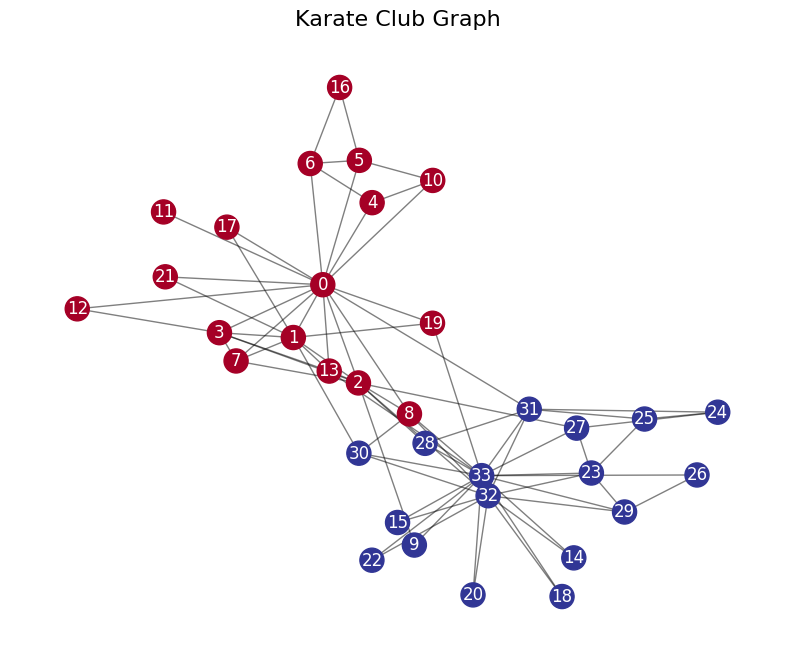

In [96]:
# Create the plot
plt.figure(figsize=(10, 8))  # Adjust figure size for better visualization
pos = nx.spring_layout(G, seed=42) # Use spring layout for better node distribution

# Draw nodes with distinct colors based on labels and increased size
nx.draw_networkx_nodes(G, pos, node_size=300, node_color=labels, cmap=plt.cm.RdYlBu) # Use a colormap for better distinction

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.5)

# Draw node labels with larger font size
nx.draw_networkx_labels(G, pos, font_size=12, font_color='white') # Specify font color for better visibility

# Customize plot aesthetics
plt.title("Karate Club Graph", fontsize=16) # Increase title font size
plt.axis('off')  # Turn off axis
plt.show()


In [97]:
# custom dataset
class KarateDataset(InMemoryDataset):
    def __init__(self, transform=None):
        super(KarateDataset, self).__init__('.', transform, None, None)

        data = Data(edge_index=edge_index)

        data.num_nodes = G.number_of_nodes()

        # embedding
        data.x = torch.from_numpy(embeddings).type(torch.float32)

        # labels
        y = torch.from_numpy(labels).type(torch.long)
        data.y = y.clone().detach()

        data.num_classes = 2

        # splitting the data into train, validation and test
        # here we do not need validation
        X_train, X_test, y_train, y_test = train_test_split(pd.Series(list(G.nodes())),
                                                            pd.Series(labels),
                                                            test_size=0.30,
                                                            random_state=42)

        n_nodes = G.number_of_nodes()

        # create train and test masks for data
        train_mask = torch.zeros(n_nodes, dtype=torch.bool)
        test_mask = torch.zeros(n_nodes, dtype=torch.bool)
        train_mask[X_train.index] = True
        test_mask[X_test.index] = True
        data['train_mask'] = train_mask
        data['test_mask'] = test_mask

        self.data, self.slices = self.collate([data])

    def _download(self):
        return

    def _process(self):
        return

    def __repr__(self):
        return '{}()'.format(self.__class__.__name__)

dataset = KarateDataset()
data = dataset[0]
print(data)

Data(edge_index=[2, 156], num_nodes=34, x=[34, 1], y=[34], num_classes=2, train_mask=[34], test_mask=[34])


In [83]:
# GCN model with 2 layers
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = GCNConv( data.num_features, 16 )
        self.conv2 = GCNConv( 16, int(data.num_classes) )

    def forward(self):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [85]:
data =  data.to(device)
print(data)

Data(edge_index=[2, 156], num_nodes=34, x=[34, 1], y=[34], num_classes=2, train_mask=[34], test_mask=[34])


In [86]:
model = Net().to(device)
print(model)

Net(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 2)
)


In [15]:
torch.manual_seed(42)

optimizer_name = "Adam"
lr = 1e-1
optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr)
epochs = 200


# The optimisation stops if one of the criteria is met
def train():
    # For details, see https://pytorch.org/docs/stable/optim.html
    model.train()
    optimizer.zero_grad()
    F.nll_loss(model()[data.train_mask], data.y[data.train_mask]).backward()
    optimizer.step()

@torch.no_grad()
def test():
    model.eval()
    logits = model()
    mask1 = data['train_mask']
    pred1 = logits[mask1].max(1)[1]
    acc1 = pred1.eq(data.y[mask1]).sum().item() / mask1.sum().item()
    mask = data['test_mask']
    pred = logits[mask].max(1)[1]
    acc = pred.eq(data.y[mask]).sum().item() / mask.sum().item()
    return acc1,acc

for epoch in range(1, epochs):
    train()

# At the end of the training process
train_acc, test_acc = test()

print('#' * 70)
print('Train Accuracy: %s' %train_acc )
print('Test Accuracy: %s' % test_acc)
print('#' * 70)

######################################################################
Train Accuracy: 0.8695652173913043
Test Accuracy: 0.7272727272727273
######################################################################


## 2. Link Prediction of Santandar Bike in London (as of Jan. 31st, 2025)

### 2.1 Data import + preprocessing from TfL API & Census

In [88]:
# get from the API
response = requests.get("https://api.tfl.gov.uk/BikePoint/")

# convert the JSON into GeoDataDrame
bike_points = gpd.GeoDataFrame(response.json())

# set geometry
bike_points = bike_points.set_geometry(gpd.points_from_xy(bike_points['lon'], bike_points['lat']), crs="EPSG:4326")

# delete unnecessary columns
bike_points.drop(['$type','url','placeType','children','childrenUrls','additionalProperties'], axis=1, inplace=True)

# clean up the name of ID
bike_points['id'] = bike_points['id'].apply(lambda x: int(x[11:]))

In [89]:
def fetch_dataset(file_name, bike_points):
  """
  This function fetches the original dataset of travel records in pd.DataFrame format

  Args:
      file_name: name of the csv file

  Returns:
      travel_df: original table in pd.DataFrame
  """

  # set the file path
  file_path = "https://cycling.data.tfl.gov.uk/usage-stats/" + file_name

  # download the travel records
  !wget -O {file_name} {file_path}

  # import the csv as a dataframe
  travel_df = pd.read_csv(file_name)

  # filter edges where nodes are in the bike_points
  travel_df = travel_df[travel_df["StartStation Id"].isin(bike_points["id"]) & travel_df["EndStation Id"].isin(bike_points["id"])]

  return travel_df

def aggregate_directed_edges(travel_df):
  """
  This function aggregates the directed edges from the dataframe of travel records in the original format.

  Args:
      travel_df: original dataframe of travel records in pd.DataFrame format.

  Returns:
      travel_df: aggregated dataframe by directed edges
  """

  # select only the start date, start station id, and end station id
  try:
    travel_df = travel_df[["Start Date", "StartStation Name", "EndStation Name"]]
    time_format = "%d/%m/%Y %H:%M"

  except:
    travel_df.rename(columns={"Start date":"Start Date", 'Start station': 'StartStation Name', 'End station': 'EndStation Name'}, inplace=True)
    travel_df = travel_df[["Start Date", "StartStation Name", "EndStation Name"]]

    time_format = "%Y-%m-%d %H:%M"

  # convert the start date into datetime
  travel_df["Start Date"] = pd.to_datetime(travel_df["Start Date"], format=time_format)

  # group by date and edge and count the number of travels
  travel_df = travel_df.groupby([travel_df["Start Date"].dt.date,
                                travel_df["StartStation Id"],
                                travel_df["EndStation Id"]]).agg(['count']).reset_index()

  # flatten multi-indices
  travel_df.columns = pd.Index(["Start Date", "StartStation Id", "EndStation Id", "count"])

  return travel_df

def aggregate_directed_edges_for_newer_api(travel_df):
  """
  This function aggregates the directed edges from the dataframe of travel records in the original format.

  Args:
      travel_df: original dataframe of travel records in pd.DataFrame format.

  Returns:
      travel_df: aggregated dataframe by directed edges
  """

  # select only the start date, start station id, and end station id
  try:
    travel_df = travel_df[["Start Date", "StartStation Name", "EndStation Name"]]
    time_format = "%d/%m/%Y %H:%M"

  except:
    travel_df.rename(columns={"Start date":"Start Date", 'Start station': 'StartStation Name', 'End station': 'EndStation Name'}, inplace=True)
    travel_df = travel_df[["Start Date", "StartStation Name", "EndStation Name"]]

    time_format = "%Y-%m-%d %H:%M"

  # convert the start date into datetime
  travel_df["Start Date"] = pd.to_datetime(travel_df["Start Date"], format=time_format)

  # group by date and edge and count the number of travels
  travel_df = travel_df.groupby([travel_df["Start Date"].dt.date,
                                travel_df["StartStation Name"],
                                travel_df["EndStation Name"]]).agg(['count']).reset_index()

  # flatten multi-indices
  travel_df.columns = pd.Index(["Start Date", "StartStation Name", "EndStation Name", "count"])

  return travel_df

def aggregate_undirected_edges(travel_df):
  """
  This function aggregates the undirected edges from the dataframe of travel records in the original format.

  Args:
      travel_df: original dataframe of travel records in pd.DataFrame format.

  Returns:
      travel_df: aggregated dataframe by undirected edges
  """

  # aggregate edges by directed edges
  travel_df = aggregate_directed_edges(travel_df)

  # create a column of frozenset of edges (permutation-invariant)
  travel_df['edge'] = travel_df.apply(lambda row: frozenset({row['StartStation Id'], row['EndStation Id']}), axis=1)

  # aggregate the both direction of the same connections
  travel_df = travel_df.groupby([travel_df["Start Date"],
                                 travel_df["edge"]]).agg({'count':['sum']}).reset_index()

  # flatten multi-indices
  travel_df.columns = pd.Index(["Start Date", "edge", "count"])

  # create a function to extract node (if self-loop return the first element)
  def extract_node(edge, idx):
    edge = list(edge)
    try:
      return edge[idx]
    except:
      return edge[0]

  # bring back the nodes
  travel_df["StartStation Id"] = travel_df["edge"].apply(extract_node, idx=0)
  travel_df["EndStation Id"]   = travel_df["edge"].apply(extract_node, idx=1)

  # delete edge column
  travel_df.drop(["edge"], axis=1, inplace=True)

  return travel_df

def aggregate_undirected_edges_for_new_api(travel_df):
  """
  This function aggregates the undirected edges from the dataframe of travel records in the original format.

  Args:
      travel_df: original dataframe of travel records in pd.DataFrame format.

  Returns:
      travel_df: aggregated dataframe by undirected edges
  """

  # aggregate edges by directed edges
  travel_df = aggregate_directed_edges_for_newer_api(travel_df)

  # create a column of frozenset of edges (permutation-invariant)
  travel_df['edge'] = travel_df.apply(lambda row: frozenset({row['StartStation Name'], row['EndStation Name']}), axis=1)

  # aggregate the both direction of the same connections
  travel_df = travel_df.groupby([travel_df["Start Date"],
                                 travel_df["edge"]]).agg({'count':['sum']}).reset_index()

  # flatten multi-indices
  travel_df.columns = pd.Index(["Start Date", "edge", "count"])

  # create a function to extract node (if self-loop return the first element)
  def extract_node(edge, idx):
    edge = list(edge)
    try:
      return edge[idx]
    except:
      return edge[0]

  # bring back the nodes
  travel_df["StartStation Name"] = travel_df["edge"].apply(extract_node, idx=0)
  travel_df["EndStation Name"]   = travel_df["edge"].apply(extract_node, idx=1)

  # delete edge column
  travel_df.drop(["edge"], axis=1, inplace=True)

  return travel_df

def fetch_dataset_for_newer_api(file_name, bike_points):
  """
  This function fetches the original dataset of travel records in pd.DataFrame format

  Args:
      file_name: name of the csv file

  Returns:
      travel_df: original table in pd.DataFrame
  """

  # set the file path
  file_path = "https://cycling.data.tfl.gov.uk/usage-stats/" + file_name

  # download the travel records
  !wget -O {file_name} {file_path}

  # import the csv as a dataframe
  travel_df = pd.read_csv(file_name)

  # filter edges where nodes are in the bike_points
  try:
    travel_df = travel_df[travel_df["Start station"].isin(bike_points["commonName"]) & travel_df["End station"].isin(bike_points["commonName"])]
  except:
    travel_df = travel_df[travel_df["StartStation Name"].isin(bike_points["commonName"]) & travel_df["EndStation Name"].isin(bike_points["commonName"])]

  return travel_df

def create_travel_df(file_name, bike_points):
  """
  This function creates download the travel records and create aggregated pd.DataFrame by undirected rows.

  Args:
      file_name: name of the file on the API of Transport for London (TfL).

  Returns:
      travel_df: aggregated pd.DataFrame of travel records
  """

  try:
    # fetch the dataset
    travel_df = fetch_dataset(file_name, bike_points)

    # aggregate rows by undirected edges
    travel_df = aggregate_undirected_edges(travel_df)

  except:
    travel_df = fetch_dataset_for_newer_api(file_name, bike_points)

    # aggregate rows by undirected edges
    travel_df = aggregate_undirected_edges_for_new_api(travel_df)

    # convert name into id
    travel_df = convert_name_to_id(travel_df, bike_points)

  return travel_df

def convert_name_to_id(travel_df, bike_points):
  """
  This function convets the name of stations into IDs in the bike_points.

  Args:
      travel_df: a dataframe of undirected edges in pd.DataFrame format.
      bike_points: a dataframe of bike points

  Returns:
      travel_df: a dataframe with name conversion into IDs.
  """

  name_id_dict = {bike_points["commonName"][idx]:bike_points["id"][idx] for idx in bike_points.index}

  travel_df['StartStation Id'] = travel_df['StartStation Name'].apply(lambda x: name_id_dict[x])
  travel_df['EndStation Id'] = travel_df['EndStation Name'].apply(lambda x: name_id_dict[x])

  travel_df.drop(["StartStation Name", "EndStation Name"], axis=1, inplace=True)

  return travel_df

def create_nx_graph(travel_df, bike_points=bike_points):
  """
  This function creates a nx.classes.graph.Graph object from travel_df and bike_points

  Args:
      travel_df: aggregated pd.DataFrame of travel records
      bike_points: nodes of bike stations

  Returns:
      G: a nx.classes.graph.Graph from the input nodes and edges
  """

  # filter edges where nodes are in the bike_points
  travel_df = travel_df[travel_df["StartStation Id"].isin(bike_points["id"]) & travel_df["EndStation Id"].isin(bike_points["id"])]

  # create a nx object
  G = nx.from_pandas_edgelist(df=travel_df, source='StartStation Id', target='EndStation Id', edge_attr='count')

  # set commonName as index
  bike_points.index = bike_points['id']

  # drop geometry
  b_p = bike_points.drop(["id", "commonName", "geometry"], axis=1)

  # add node attributes into the graph
  nx.set_node_attributes(G, b_p.to_dict('index'))

  return G

In [90]:
travel_record_paths = ["412JourneyDataExtract15Jan2025-31Jan2025.csv"]

# initialize a dictionary of graphs
G_dict = {}

# set the file name and path (ex. first ten)
file_names = travel_record_paths

# iterate over file_names
for fn in file_names:

  # create a travel_df all at once
  travel_df = create_travel_df(fn, bike_points)

  # create graphs by date
  dates = travel_df["Start Date"].unique()
  G_dict.update({date.strftime("%Y-%m-%d"): create_nx_graph(travel_df[travel_df["Start Date"] == date]) for date in dates})
  os.remove("/content/" + fn)

# release memory
gc.collect()

# save G_dict
with open("/content/G_dict.pickle", 'wb') as pickle_file:
    pickle.dump(G_dict, pickle_file)

travel_df = create_travel_df("412JourneyDataExtract15Jan2025-31Jan2025.csv", bike_points)

--2025-04-21 17:23:28--  https://cycling.data.tfl.gov.uk/usage-stats/412JourneyDataExtract15Jan2025-31Jan2025.csv
Resolving cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)... 104.16.97.104, 104.16.98.104
Connecting to cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)|104.16.97.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58964720 (56M) [text/csv]
Saving to: ‘412JourneyDataExtract15Jan2025-31Jan2025.csv’

412JourneyDataExtra 100%[===================>]  56.23M   182MB/s    in 0.3s    

2025-04-21 17:23:28 (182 MB/s) - ‘412JourneyDataExtract15Jan2025-31Jan2025.csv’ saved [58964720/58964720]

--2025-04-21 17:23:29--  https://cycling.data.tfl.gov.uk/usage-stats/412JourneyDataExtract15Jan2025-31Jan2025.csv
Resolving cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)... 104.16.97.104, 104.16.98.104
Connecting to cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)|104.16.97.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58964720 (5

<ipython-input-89-d578f3e09996>:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  travel_df["Start Date"] = pd.to_datetime(travel_df["Start Date"], format=time_format)


--2025-04-21 17:23:38--  https://cycling.data.tfl.gov.uk/usage-stats/412JourneyDataExtract15Jan2025-31Jan2025.csv
Resolving cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)... 104.16.97.104, 104.16.98.104
Connecting to cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)|104.16.97.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58964720 (56M) [text/csv]
Saving to: ‘412JourneyDataExtract15Jan2025-31Jan2025.csv’

412JourneyDataExtra 100%[===================>]  56.23M   248MB/s    in 0.2s    

2025-04-21 17:23:38 (248 MB/s) - ‘412JourneyDataExtract15Jan2025-31Jan2025.csv’ saved [58964720/58964720]

--2025-04-21 17:23:39--  https://cycling.data.tfl.gov.uk/usage-stats/412JourneyDataExtract15Jan2025-31Jan2025.csv
Resolving cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)... 104.16.97.104, 104.16.98.104
Connecting to cycling.data.tfl.gov.uk (cycling.data.tfl.gov.uk)|104.16.97.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58964720 (5

<ipython-input-89-d578f3e09996>:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  travel_df["Start Date"] = pd.to_datetime(travel_df["Start Date"], format=time_format)


### 2.2 Data Overview

In [55]:
def vizualize_travels(travel_df, bike_points):
  # reset index for bike_points
  bike_points = bike_points.reset_index(drop=True)

  # merge with bike_points for the station ID and the coordinates
  viz = pd.merge(travel_df, bike_points, left_on='StartStation Id', right_on='id')
  viz = viz.merge(bike_points, left_on='EndStation Id', right_on='id', suffixes=['_start', '_end'])


  # replace the station ID with the one from bike_points
  viz['Start station number'] = viz['id_start']
  viz['End station number']   = viz['id_end']

  # delete unnecessary columns
  viz.drop(['id_start','id_end', 'commonName_start', 'commonName_end', 'lat_start', 'lon_start', 'lat_end', 'lon_end'], axis=1, inplace=True)

  # create edges from the nodes
  viz['route'] = viz.apply(lambda row: LineString([row['geometry_start'], row['geometry_end']]), axis=1)

  # set geometry
  viz = viz.set_geometry(viz['route'], crs='EPSG:4326')

  # change the coordinate reference system for London
  viz = viz.to_crs("EPSG:27700")
  bike_points = bike_points.to_crs("EPSG:27700")

  # static map vizualisation
  ax = viz.plot(figsize=(15,15), alpha=.15, edgecolor='b', linewidth=.5)
  bike_points.plot(ax=ax, marker='o', color='black', markersize=15)
  cx.add_basemap(ax, zoom=14, crs=viz.crs, source=cx.providers.CartoDB.Positron)
  plt.axis('off')

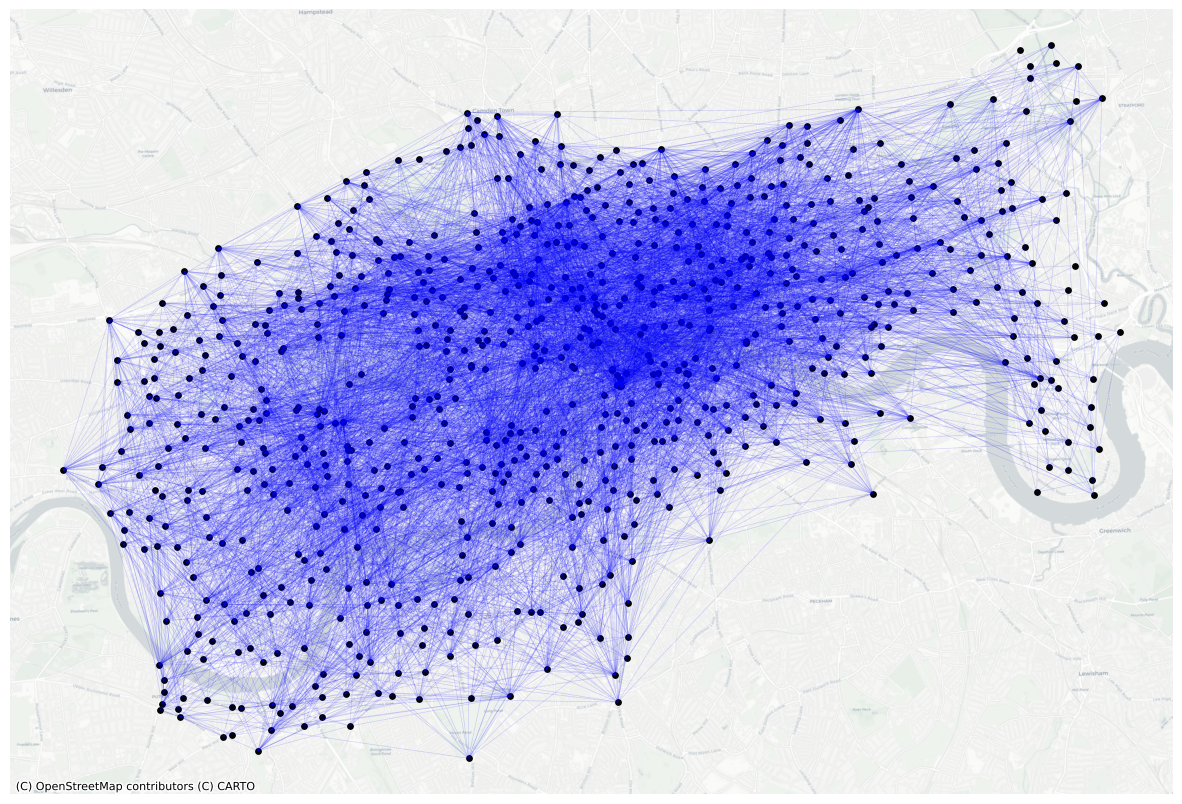

In [65]:
# vizualize the edges (if needed)
vizualize_travels(travel_df[travel_df["Start Date"] == datetime.date(2025, 1, 31)], bike_points)

### 2.3 Link prediction

In [ ]:
from torch_geometric.utils import from_networkx, degree
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import mean_squared_error, r2_score

# Convert networkx graph to PyG Data
G_bike = create_nx_graph(grouped_df, bike_points)
data_er = from_networkx(G_bike)  # Use 'data_er' for edge regression
data_er.num_nodes = G_bike.number_of_nodes()
data_er.edge_attr = data_er.count.clone().detach().type(torch.float)  # Ensure edge_attr is a PyTorch tensor

transform = RandomLinkSplit(is_undirected=True,
                            add_negative_train_samples=False,
                            num_val=0.1,
                            num_test=0.2)

# Assign the output to separate variables
train_data, val_data, test_data = transform(data_er)

# Move edge attributes to train_data, val_data and test_data manually,
# after the split to ensure proper assignment
train_data.edge_attr = train_data.count.clone().detach().type(torch.float)
val_data.edge_attr = val_data.count.clone().detach().type(torch.float)
test_data.edge_attr = test_data.count.clone().detach().type(torch.float)

# Create node features based on degree
train_data.x = degree(train_data.edge_index[0], train_data.num_nodes).unsqueeze(1)
val_data.x = degree(val_data.edge_index[0], val_data.num_nodes).unsqueeze(1)
test_data.x = degree(test_data.edge_index[0], test_data.num_nodes).unsqueeze(1)

class EdgeRegressionModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, mlp_hidden=16):
        super(EdgeRegressionModel, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.mlp = nn.Sequential(
            nn.Linear(2*out_channels, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_edge_attr(self, z, edge_index):
        row, col = edge_index
        edge_z = torch.cat([z[row], z[col]], dim=1)
        return self.mlp(edge_z).squeeze()

# Instantiate model
in_channels = 1  # Dimension of node features (dummy features here)
hidden_channels = 32  # Number of hidden units
out_channels = 16  # Dimension of output embeddings

model_er = EdgeRegressionModel(in_channels, hidden_channels, out_channels).to(device)
optimizer_er = torch.optim.Adam(model_er.parameters(), lr=0.01)

# Training loop
for epoch in range(1, 101):
    model_er.train()
    optimizer_er.zero_grad()
    z = model_er(train_data.x, train_data.edge_index)
    edge_attr_pred = model_er.predict_edge_attr(z, train_data.edge_index)
    loss = F.mse_loss(edge_attr_pred, train_data.edge_attr)
    loss.backward()
    optimizer_er.step()
    print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")

# Evaluation
model_er.eval()
z = model_er(test_data.x, test_data.edge_index)  # Get node embeddings for test data

# Predict edge attributes for test data
edge_attr_pred_test = model_er.predict_edge_attr(z, test_data.edge_index)

# Calculate evaluation metrics (e.g., MSE, R-squared)
mse = mean_squared_error(test_data.edge_attr.cpu().detach().numpy(), edge_attr_pred_test.cpu().detach().numpy())  # Detach before converting to NumPy
r2 = r2_score(test_data.edge_attr.cpu().detach().numpy(), edge_attr_pred_test.cpu().detach().numpy())  # Detach before converting to NumPy

print(f"Test MSE: {mse:.4f}")
print(f"Test R-squared: {r2:.4f}")

## 3. Others

In [9]:
!git clone https://github.com/yu-ta-sato/city2graph.git

!pip install -r /content/city2graph/requirements.txt

import sys
sys.path.append('/content/city2graph/city2graph')

import city2graph

Cloning into 'city2graph'...
remote: Enumerating objects: 1025, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 1025 (delta 44), reused 39 (delta 27), pack-reused 949 (from 1)
Receiving objects: 100% (1025/1025), 42.87 MiB | 20.91 MiB/s, done.
Resolving deltas: 100% (645/645), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.7 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='data/TUDataset', name='MUTAG')

Processing...
Done!


In [ ]:
dataset

MUTAG(188)

In [ ]:
ningning_beutiful = True

ningning_loves_yuta = True
yuta_loves_ningning = True

while ningning_beutiful:
    if ningning_loves_yuta and yuta_loves_ningning:
        print("Ningning loves Yuta and Yuta loves Ningning")
        continue
    else:
        print("Ningning is beautiful")
        continue
    ningning_beutiful = False\